In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '/Volumes/Elements/PTM_project/FLNA21/METAD_repeat/DATA_PLUMED/'
path2 = '/Volumes/Elements/PTM_project/FLNA21/METAD/DATA_PLUMED/'

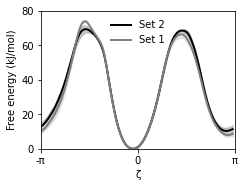

In [7]:
# average 1D FELs from the triplicates

plt.figure(figsize = (3.5,2.7))

### repeat ###

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)




plt.plot(x[:-1],mu,color = 'black',linewidth=2, label='Set 2')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)

### first set ###

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path2+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)




plt.plot(x[:-1],mu,color = 'grey',linewidth=2, label='Set 1')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'grey',alpha = 0.2)
    
# formatting

plt.xlabel('\u03B6')
plt.xlim(-np.pi,np.pi)
plt.ylim(0,80)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=['-\u03C0',0,'\u03C0'])
plt.ylabel('Free energy (kJ/mol)')
plt.legend(frameon=False)


plt.tight_layout()
plt.savefig('ZETA_comparison.pdf')

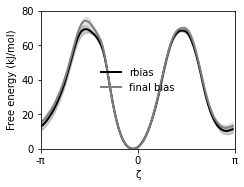

In [8]:
# FEL comparison rbias vs final bias

# average 1D FELs from the triplicates

plt.figure(figsize = (3.5,2.7))

### repeat rbias reweighting ###

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)




plt.plot(x[:-1],mu,color = 'black',linewidth=2, label='rbias')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)

### repeat final bias reweighting ###

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/20) # 20 ps frequency for COLVAR_REW
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[:frame],weights=weights,bins=100)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)


plt.plot(x[:-1],mu,color = 'grey',linewidth=2, label='final bias')
plt.fill_between(x[:-1],mu-err,mu+err,color = 'grey',alpha = 0.2)
    
# formatting

plt.xlabel('\u03B6')
plt.xlim(-np.pi,np.pi)
plt.ylim(0,80)
plt.xticks(ticks=[-np.pi,0,np.pi],labels=['-\u03C0',0,'\u03C0'])
plt.ylabel('Free energy (kJ/mol)')
plt.legend(frameon=False)


plt.tight_layout()
plt.savefig('ZETA_comparison_reweighting_method.pdf')